## ۱. تعریف مدل IAFMNet
تکنیک‌ها: IDE → IDM → top-k mask → IGRA → ARM → IFEB → PixelShuffle

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import math
from torch.distributions import Normal


def topk_mask(idm, keep_ratio=0.05):
    b, _, h, w = idm.shape
    flat = idm.view(b, -1)
    k = max(1, int(flat.shape[1] * keep_ratio))
    threshold = torch.topk(flat, k, dim=1).values[:, -1].view(b, 1, 1, 1)
    return (idm >= threshold).float()

def information_entropy_loss(mu, theta, features, eps=1e-9):

    noise = torch.rand_like(features) - 0.5
    f_hat = features + noise

    theta = torch.clamp(theta, min=1e-6)

    dist = Normal(mu, theta)

    prob = dist.cdf(f_hat + 0.5) - dist.cdf(f_hat - 0.5)

    prob = torch.clamp(prob, min=eps)

    loss = -torch.log2(prob)

    return loss.mean()

class LowerBound(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, bound):
        ctx.save_for_backward(x, bound)
        return torch.max(x, bound)

    @staticmethod
    def backward(ctx, grad_output):
        x, bound = ctx.saved_tensors
        pass_through = (x >= bound) | (grad_output < 0)
        return pass_through.type(grad_output.dtype) * grad_output, None


def lower_bound(x, bound):
    return LowerBound.apply(x, torch.tensor(bound, device=x.device))


class GDN(nn.Module):

    def __init__(
        self,
        channels,
        inverse=False,
        beta_min=1e-6,
        gamma_init=0.1,
        reparam_offset=2**-18,
    ):
        super().__init__()

        self.inverse = inverse
        self.beta_min = beta_min
        self.reparam_offset = reparam_offset

        pedestal = reparam_offset ** 2

        beta = torch.sqrt(torch.ones(channels) + pedestal)
        gamma = torch.sqrt(
            gamma_init * torch.eye(channels) + pedestal
        )

        self.beta = nn.Parameter(beta)
        self.gamma = nn.Parameter(gamma)

        self.pedestal = pedestal

    def forward(self, x):

        beta = lower_bound(self.beta, self.beta_min)
        beta = beta ** 2 - self.pedestal

        gamma = lower_bound(self.gamma, 0)
        gamma = gamma ** 2 - self.pedestal
        gamma = gamma.view(
            gamma.size(0),
            gamma.size(1),
            1,
            1
        )

        norm = F.conv2d(
            x ** 2,
            gamma,
            beta
        )

        norm = torch.sqrt(norm)

        if self.inverse:
            return x * norm
        else:
            return x / norm

class InformationDensityEstimator(nn.Module):

    def __init__(self, ch):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1),
            GDN(ch)
        )

        self.mu_head = nn.Conv2d(ch, ch, 1)

        self.theta_head = nn.Sequential(
            nn.Conv2d(ch, ch, 1),
            nn.Softplus()
        )

    def forward(self, f):
        x = self.shared(f)
        mu = self.mu_head(x)
        theta = self.theta_head(x) + 1e-6
        return mu, theta

class InformationGuidedResourceAllocation(nn.Module):
    def __init__(self, ch, keep_ratio=0.05):
        super().__init__()
        self.keep_ratio = keep_ratio
        self.branch = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1))
    def forward(self, f, idm):
        mask = topk_mask(idm, self.keep_ratio)
        return f + mask * self.branch(f)

class AffineRecalibrationModule(nn.Module):

    def __init__(self, ch):
        super().__init__()
        self.local = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, groups=ch),
            nn.Conv2d(ch, ch, 1),
            nn.ReLU(inplace=True)
        )

        self.scale = nn.Sequential(
            nn.Conv2d(ch * 2, ch, 1),
            nn.Sigmoid()
        )

    def forward(self, f, mu):

        local = self.local(f)
        s = self.scale(torch.cat([f, mu], dim=1))
        return local * s

class InformationGuidedFeatureEnhancementBlock(nn.Module):

    def __init__(self, ch, keep_ratio=0.05):
        super().__init__()

        self.pre = nn.Conv2d(ch, ch * 2, kernel_size=1)

        self.igra = InformationGuidedResourceAllocation(
            ch,
            keep_ratio
        )

        self.arm = AffineRecalibrationModule(ch)

        self.fuse = nn.Conv2d(ch, ch, kernel_size=1)

    def forward(self, f, idm, mu):

        left, right = self.pre(f).chunk(2, dim=1)

        igra_feat = self.igra(left, idm)

        arm_feat = self.arm(right, mu)

        out = self.fuse(
            igra_feat + arm_feat
        )

        return f + out

class MiniIAFMNet(nn.Module):

    def __init__(self,
                 scale=4,
                 ch=24,
                 blocks=3,
                 keep_ratio=0.05):

        super().__init__()

        self.scale = scale

        # Shallow Feature Extraction
        self.head = nn.Conv2d(
            3,
            ch,
            kernel_size=3,
            padding=1
        )

        # Information Density Estimation
        self.ide = InformationDensityEstimator(ch)

        # IFEB
        self.blocks = nn.ModuleList(
            [
                InformationGuidedFeatureEnhancementBlock(
                    ch,
                    keep_ratio
                )
                for _ in range(blocks)
            ]
        )

        # Reconstruction
        self.tail = nn.Conv2d(
            ch,
            3 * scale * scale,
            kernel_size=3,
            padding=1
        )

        self.shuffle = nn.PixelShuffle(scale)

    def forward(self, x):

        f = self.head(x)

        # IDE
        mu, theta = self.ide(f)

        # IFEB
        for blk in self.blocks:

            f = blk(
                f,
                theta,
                mu
            )

        # Reconstruction
        sr = self.shuffle(
            self.tail(f)
        )

        # Global Residual
        sr = sr + F.interpolate(
            x,
            scale_factor=self.scale,
            mode="bicubic",
            align_corners=False,
        )

        return sr, mu, theta, f
# Quick Test

m = MiniIAFMNet(scale=4)

x = torch.randn(1, 3, 64, 64)

sr, mu, theta, f = m(x)

print(f"Input : {tuple(x.shape)}")
print(f"SR    : {tuple(sr.shape)}")
print(f"μ Map : {tuple(mu.shape)}")
print(f"θ Map : {tuple(theta.shape)}")
print(f"features : {tuple(f.shape)}")

print("✅ Model runs successfully!")

Input : (1, 3, 64, 64)
SR    : (1, 3, 256, 256)
μ Map : (1, 24, 64, 64)
θ Map : (1, 24, 64, 64)
features : (1, 24, 64, 64)
✅ Model runs successfully!


## ۲. دانلود و آماده‌سازی DIV2K
۸۰۰ عکس واقعی با کیفیت بالا + نسخه کم‌کیفیت x4

In [3]:
import requests, zipfile
from pathlib import Path
import numpy as np

base = Path('data/div2k')
base.mkdir(parents=True, exist_ok=True)

urls = {
    'DIV2K_train_HR.zip': 'https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip',
    'DIV2K_train_LR_bicubic_X4.zip': 'https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_LR_bicubic_X4.zip',
}

for fname, url in urls.items():
    out = base / fname
    if out.exists():
        print(f'✅ موجود: {fname}')
        continue
    print(f'دانلود {fname}...')
    r = requests.get(url, stream=True, timeout=300)
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))
    dl = 0
    with open(out, 'wb') as f:
        for chunk in r.iter_content(1024*1024):
            f.write(chunk)
            dl += len(chunk)
            if total: print(f'  {dl*100//total}%', end='\r')
    print(f'  ✅ ذخیره شد ({out.stat().st_size//1024//1024}MB)')

for fname in urls:
    zp = base / fname
    if zp.exists():
        with zipfile.ZipFile(zp) as z:
            z.extractall(base)
        print(f'✅ استخراج {fname}')

hr_count = len(list((base / 'DIV2K_train_HR').glob('*.png')))
lr_count = len(list((base / 'DIV2K_train_LR_bicubic/X4').glob('*.png')))
print(f'\n✅ DIV2K آماده: {hr_count} تصویر HR + {lr_count} تصویر LR')

✅ موجود: DIV2K_train_HR.zip
✅ موجود: DIV2K_train_LR_bicubic_X4.zip
✅ استخراج DIV2K_train_HR.zip
✅ استخراج DIV2K_train_LR_bicubic_X4.zip

✅ DIV2K آماده: 800 تصویر HR + 800 تصویر LR


In [4]:
import cv2
import random
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader


class DIV2KDataset(Dataset):
    def __init__(
        self,
        hr_dir,
        lr_dir,
        patch=64,
        scale=4,
        augment=True,
        patches_per_image=32,
    ):

        self.hr_paths = sorted(hr_dir.glob("*.png"))
        self.lr_dir = lr_dir

        self.patch = patch
        self.scale = scale
        self.augment = augment
        self.patches_per_image = patches_per_image

    def __len__(self):
        return len(self.hr_paths) * self.patches_per_image

    def __getitem__(self, idx):

        idx = idx % len(self.hr_paths)

        hr_path = self.hr_paths[idx]
        stem = hr_path.stem

        lr_path = self.lr_dir / f"{stem}x4.png"

        # OpenCV reads BGR -> convert to RGB
        hr = cv2.imread(str(hr_path), cv2.IMREAD_COLOR)
        lr = cv2.imread(str(lr_path), cv2.IMREAD_COLOR)

        hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)
        lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)

        h, w = hr.shape[:2]

        ps = self.patch

        y = random.randint(0, h - ps)
        x = random.randint(0, w - ps)

        hr_crop = hr[y:y + ps, x:x + ps].copy()

        lps = ps // self.scale

        ly = y // self.scale
        lx = x // self.scale

        lr_crop = lr[
            ly:ly + lps,
            lx:lx + lps
        ].copy()

        if self.augment:

            if random.random() < 0.5:
                hr_crop = np.flip(hr_crop, axis=1).copy()
                lr_crop = np.flip(lr_crop, axis=1).copy()

            if random.random() < 0.5:
                hr_crop = np.flip(hr_crop, axis=0).copy()
                lr_crop = np.flip(lr_crop, axis=0).copy()

        lr_tensor = (
            torch.from_numpy(lr_crop)
            .permute(2, 0, 1)
            .float()
            / 255.0
        )

        hr_tensor = (
            torch.from_numpy(hr_crop)
            .permute(2, 0, 1)
            .float()
            / 255.0
        )

        return lr_tensor, hr_tensor


dataset = DIV2KDataset(
    hr_dir=Path("data/div2k/DIV2K_train_HR"),
    lr_dir=Path("data/div2k/DIV2K_train_LR_bicubic/X4"),
    patch=64,
    scale=4,
    augment=True,
)

print(f"✅ Dataset Ready")
print(f"Images           : {len(dataset.hr_paths)}")
print(f"Patches / Image  : {dataset.patches_per_image}")
print(f"Total Samples    : {len(dataset)}")

✅ Dataset Ready
Images           : 800
Patches / Image  : 32
Total Samples    : 25600


## ۳. آموزش مدل روی DIV2K

In [ ]:
import itertools
import json
import time
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader


STEPS = 2000
BATCH = 4
LR_RATE = 1e-4
LAMBDA_IE = 0.01


dl = DataLoader(
    dataset,
    batch_size=BATCH,
    shuffle=True,
    drop_last=True,
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MiniIAFMNet(scale=4).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR_RATE
)

l1_loss = nn.L1Loss()


history = []

best_sr_loss = float("inf")

t0 = time.time()

model.train()

for step, (lr_batch, hr_batch) in enumerate(itertools.cycle(dl), 1):

    lr_batch = lr_batch.to(device)
    hr_batch = hr_batch.to(device)

    sr, mu, theta, features = model(lr_batch)

    sr_loss = l1_loss(sr, hr_batch)

    ie_loss = information_entropy_loss(
        mu,
        theta,
        features
    )

    loss = sr_loss + LAMBDA_IE * ie_loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    history.append(
        {
            "step": step,
            "loss": loss.item(),
            "sr_loss": sr_loss.item(),
            "ie_loss": ie_loss.item(),
        }
    )

    best_sr_loss = min(
        best_sr_loss,
        sr_loss.item()
    )

    if step == 1 or step % 50 == 0:

        print(
            f"Step {step:5d} | "
            f"Total: {loss:.4f} | "
            f"SR: {sr_loss:.4f} | "
            f"IE: {ie_loss:.4f}"
        )

    if step >= STEPS:
        break

save_dir = Path("checkpoints_div2k")

save_dir.mkdir(exist_ok=True)

torch.save(
    model.state_dict(),
    save_dir / "iafmnet_final.pth"
)

with open(
    save_dir / "history.json",
    "w"
) as f:

    json.dump(
        history,
        f,
        indent=4
    )


elapsed = time.time() - t0

print()
print("=" * 50)
print("✅ Training Finished")
print(f"Elapsed Time : {elapsed:.1f} sec")
print(f"Best SR Loss : {best_sr_loss:.6f}")
print("=" * 50)

Step     1 | Total: 0.2076 | SR: 0.1949 | IE: 1.2719
Step    50 | Total: 0.1009 | SR: 0.0897 | IE: 1.1203
Step   100 | Total: 0.0954 | SR: 0.0852 | IE: 1.0250
Step   150 | Total: 0.0738 | SR: 0.0646 | IE: 0.9151
Step   200 | Total: 0.0744 | SR: 0.0664 | IE: 0.8065
Step   250 | Total: 0.0489 | SR: 0.0419 | IE: 0.6948
Step   300 | Total: 0.0814 | SR: 0.0759 | IE: 0.5505
Step   350 | Total: 0.0583 | SR: 0.0533 | IE: 0.5002
Step   400 | Total: 0.0393 | SR: 0.0352 | IE: 0.4037
Step   450 | Total: 0.0265 | SR: 0.0235 | IE: 0.2965
Step   500 | Total: 0.0521 | SR: 0.0498 | IE: 0.2277
Step   550 | Total: 0.0332 | SR: 0.0307 | IE: 0.2443
Step   600 | Total: 0.0460 | SR: 0.0438 | IE: 0.2204
Step   650 | Total: 0.0420 | SR: 0.0400 | IE: 0.2017
Step   700 | Total: 0.0769 | SR: 0.0750 | IE: 0.1861
Step   750 | Total: 0.0464 | SR: 0.0449 | IE: 0.1499
Step   800 | Total: 0.0426 | SR: 0.0410 | IE: 0.1575
Step   850 | Total: 0.0641 | SR: 0.0624 | IE: 0.1680
Step   900 | Total: 0.0500 | SR: 0.0488 | IE: 

## ۴. نمودار Loss
بررسی کن مدل واقعاً یاد گرفته یا نه

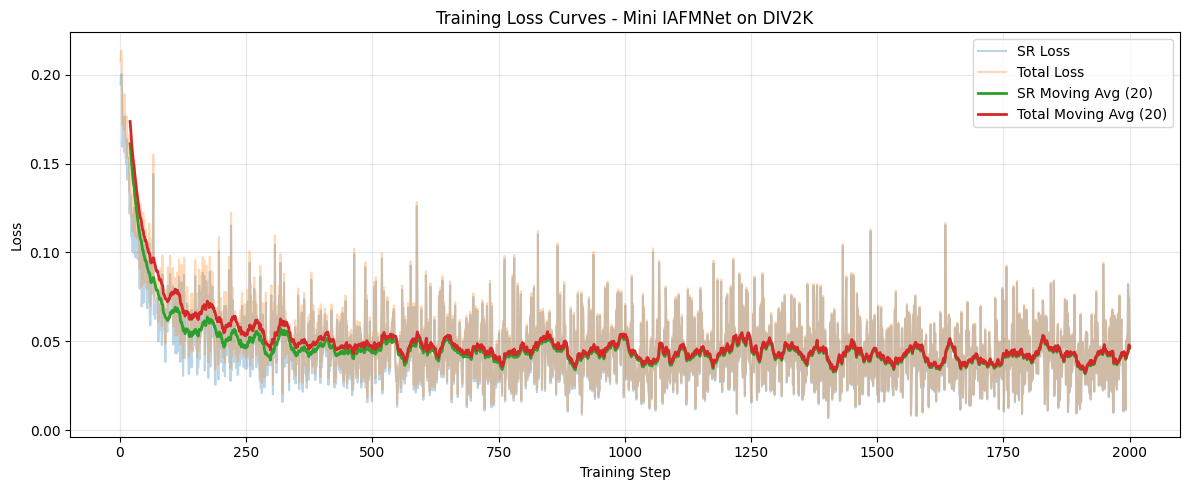

Initial SR Loss   : 0.1949
Best SR Loss      : 0.0066
Improvement       : 96.6%

Final IE Loss     : 0.0558
Final Total Loss  : 0.0491


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


steps = [h["step"] for h in history]

sr_losses = [h["sr_loss"] for h in history]
ie_losses = [h["ie_loss"] for h in history]
total_losses = [h["loss"] for h in history]


plt.figure(figsize=(12, 5))

plt.plot(
    steps,
    sr_losses,
    alpha=0.3,
    label="SR Loss"
)

plt.plot(
    steps,
    total_losses,
    alpha=0.3,
    label="Total Loss"
)

window = 20

if len(sr_losses) > window:

    sr_avg = np.convolve(
        sr_losses,
        np.ones(window) / window,
        mode="valid"
    )

    total_avg = np.convolve(
        total_losses,
        np.ones(window) / window,
        mode="valid"
    )

    plt.plot(
        steps[window - 1:],
        sr_avg,
        linewidth=2,
        label=f"SR Moving Avg ({window})"
    )

    plt.plot(
        steps[window - 1:],
        total_avg,
        linewidth=2,
        label=f"Total Moving Avg ({window})"
    )


plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.title("Training Loss Curves - Mini IAFMNet on DIV2K")

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()


print("=" * 50)
print(f"Initial SR Loss   : {sr_losses[0]:.4f}")
print(f"Best SR Loss      : {best_sr_loss:.4f}")
print(f"Improvement       : {(1-best_sr_loss/sr_losses[0])*100:.1f}%")
print()
print(f"Final IE Loss     : {ie_losses[-1]:.4f}")
print(f"Final Total Loss  : {total_losses[-1]:.4f}")
print("=" * 50)

## ۵. تست روی عکس واقعی DIV2K

## ۶. اینترفیس وب (Gradio)
عکس آپلود کن → خروجی SR بگیر

بعد اجرا: `http://localhost:7860`

HR : 2040 x 1404
LR : 510 x 351


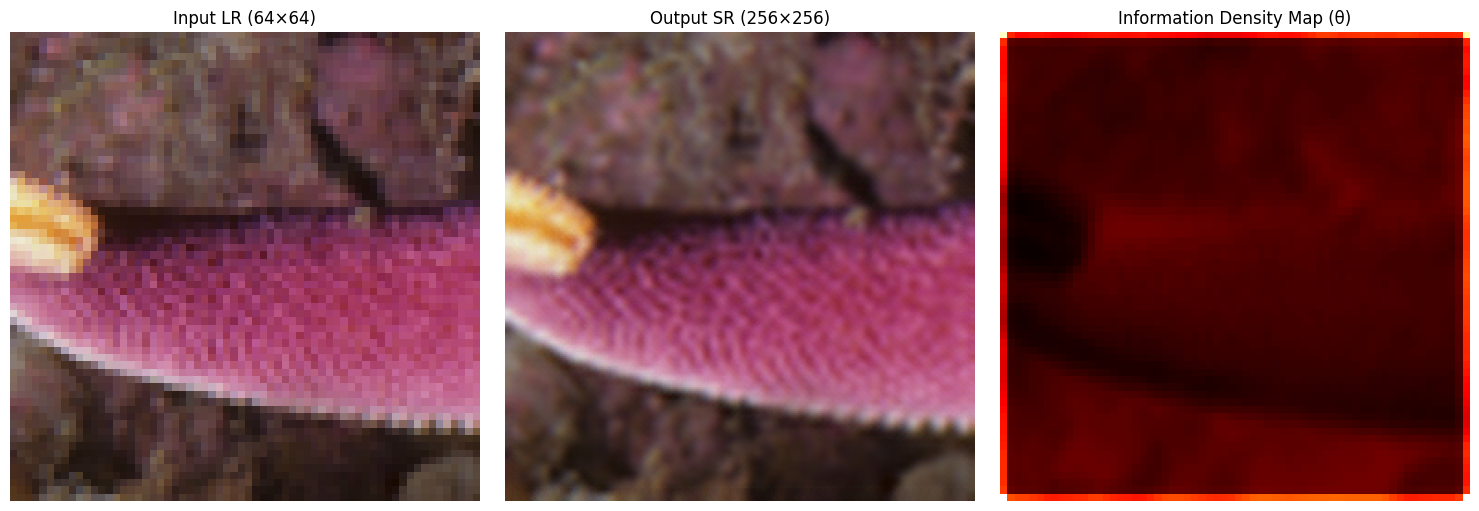

✅ Inference completed successfully.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

model.eval()

device = next(model.parameters()).device

hr_path = Path("data/div2k/DIV2K_train_HR/0001.png")
lr_path = Path("data/div2k/DIV2K_train_LR_bicubic/X4/0001x4.png")

hr = cv2.imread(str(hr_path))
lr = cv2.imread(str(lr_path))

hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)
lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)

print(f"HR : {hr.shape[1]} x {hr.shape[0]}")
print(f"LR : {lr.shape[1]} x {lr.shape[0]}")

y = min(100, lr.shape[0] - 64)
x = min(100, lr.shape[1] - 64)

lr_crop = lr[
    y:y+64,
    x:x+64
]

with torch.no_grad():

    t = (
        torch.from_numpy(lr_crop.copy())
        .permute(2, 0, 1)
        .float()
        .unsqueeze(0)
        / 255.0
    ).to(device)

    sr, mu, theta, features = model(t)

sr_np = (
    sr[0]
    .cpu()
    .permute(1, 2, 0)
    .numpy()
)

sr_np = (
    sr_np * 255
).clip(
    0,
    255
).astype(
    np.uint8
)

theta_np = (
    theta[0]
    .mean(0)
    .cpu()
    .numpy()
)

theta_np = (
    255 * (
        theta_np - theta_np.min()
    ) / (
        theta_np.max() - theta_np.min() + 1e-8
    )
).astype(
    np.uint8
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

axes[0].imshow(lr_crop)
axes[0].set_title(
    f"Input LR ({lr_crop.shape[1]}×{lr_crop.shape[0]})"
)

axes[1].imshow(sr_np)
axes[1].set_title(
    f"Output SR ({sr_np.shape[1]}×{sr_np.shape[0]})"
)

axes[2].imshow(
    theta_np,
    cmap="hot"
)
axes[2].set_title("Information Density Map (θ)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

plt.show()

print("✅ Inference completed successfully.")

In [ ]:
import gradio as gr
import numpy as np
import torch


model.eval()

device = next(model.parameters()).device

def super_resolve(image):

    try:

        print("\n========== New Request ==========")

        # Check input
        print("Input type:", type(image))
        print("Input shape:", image.shape)


        # Remove Alpha channel if exists (RGBA -> RGB)
        if image.shape[2] == 4:
            image = image[:, :, :3]


        h, w = image.shape[:2]


        # Padding for scale x4
        ph = (4 - h % 4) % 4
        pw = (4 - w % 4) % 4


        if ph or pw:

            image = np.pad(
                image,
                (
                    (0, ph),
                    (0, pw),
                    (0, 0)
                ),
                mode="reflect"
            )

        x = (
            torch.from_numpy(image.copy())
            .permute(2, 0, 1)
            .float()
            .unsqueeze(0)
            / 255.0
        ).to(device)


        print("Tensor:", x.shape)
        print("Device:", x.device)

        with torch.no_grad():

            output = model(x)


        print("Model outputs:", len(output))


        if len(output) == 4:

            sr, mu, theta, features = output

        elif len(output) == 3:

            sr, mu, theta = output

        else:

            raise RuntimeError(
                f"Unexpected model output count: {len(output)}"
            )


        print("SR:", sr.shape)
        print("Theta:", theta.shape)

        sr = (
            sr[0]
            .cpu()
            .permute(1, 2, 0)
            .numpy()
        )


        sr = (
            sr * 255
        ).clip(
            0,
            255
        ).astype(
            np.uint8
        )

        sr = sr[
            :h * 4,
            :w * 4
        ]

        theta_map = (
            theta[0]
            .mean(0)
            .detach()
            .cpu()
            .numpy()
        )


        t_min = theta_map.min()
        t_max = theta_map.max()


        theta_map = (
            theta_map - t_min
        ) / (
            t_max - t_min + 1e-8
        )


        theta_map = (
            theta_map * 255
        ).astype(
            np.uint8
        )


        print("Output SR:", sr.shape)
        print("Output Theta:", theta_map.shape)

        print("========== Done ==========\n")


        return sr, theta_map


    except Exception as e:

        print("\n######## ERROR ########")
        print(type(e).__name__)
        print(e)
        print("#######################\n")

        return None, None


with gr.Blocks(
    title="Mini IAFMNet"
) as demo:


    gr.Markdown(
        "# Mini IAFMNet Super-Resolution"
    )


    gr.Markdown(
        "Upload a Low-Resolution Image and Generate a ×4 Super-Resolved Image."
    )


    with gr.Row():


        inp = gr.Image(
            type="numpy",
            label="Input Image"
        )


        with gr.Column():

            out_sr = gr.Image(
                type="numpy",
                label="Super-Resolved Image"
            )


            out_theta = gr.Image(
                type="numpy",
                label="Information Density Map (θ)"
            )



    btn = gr.Button(
        "Super Resolve"
    )


    btn.click(
        fn=super_resolve,
        inputs=inp,
        outputs=[
            out_sr,
            out_theta
        ]
    )


demo.close()
demo.launch(
    server_name="0.0.0.0",
    server_port=7860,
    share=False,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

Keyboard interruption in main thread... closing server.
